In [1]:
!pip install -q tensorflow-datasets
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [2]:
dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

train_data = dataset['train']
test_data = dataset['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.N45OFW_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.N45OFW_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(data):
    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0
     # convert labels (1,2,3) → (0,1,2)
    mask = mask - 1

    return image, mask

In [4]:

train = (train_data.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

In [5]:

test = (test_data.map(preprocess).batch(BATCH_SIZE))

In [6]:
def unet_model():
    inputs = tf.keras.layers.Input((128,128,3))

    # Encoder
    c1 = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D()(c1)

    c2 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D()(c2)

    # Bottleneck
    b = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = tf.keras.layers.UpSampling2D()(b)
    u1 = tf.keras.layers.Concatenate()([u1, c2])
    c3 = tf.keras.layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = tf.keras.layers.UpSampling2D()(c3)
    u2 = tf.keras.layers.Concatenate()([u2, c1])
    c4 = tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = tf.keras.layers.Conv2D(3, 1, activation='softmax')(c4)

    return tf.keras.Model(inputs, outputs)



In [7]:
model = unet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │         51 │ conv2d_6[0][0]    │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,811 (272.70 KB)

 Trainable params: 69,811 (272.70 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train,
    validation_data=test,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 535s 5s/step - accuracy: 0.5865 - loss: 0.8751 - val_accuracy: 0.6489 - val_loss: 0.7662
Epoch 2/10
 43/115 ━━━━━━━━━━━━━━━━━━━━ 4:37 4s/step - accuracy: 0.6568 - loss: 0.7536

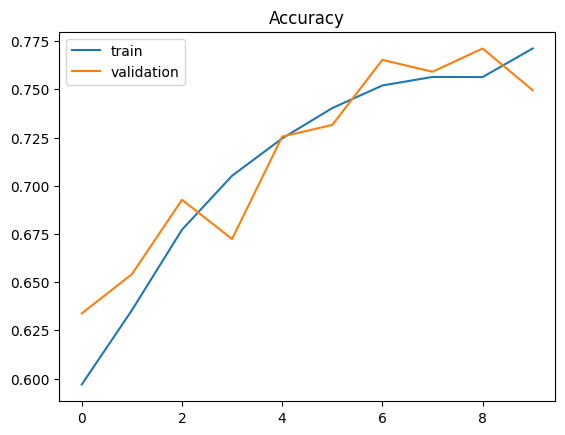

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
def display_sample(image, mask, pred_mask):
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Input Image")
    plt.imshow(image)

    plt.subplot(1,3,2)
    plt.title("True Mask")
    plt.imshow(mask[:,:,0])

    plt.subplot(1,3,3)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask)

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step


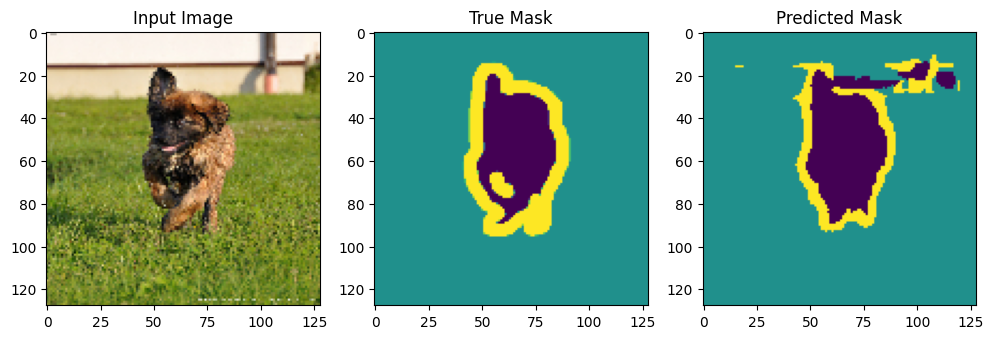

In [ ]:
for images, masks in test.take(1):
    preds = model.predict(images)
    pred_masks = tf.argmax(preds, axis=-1)

    display_sample(images[0], masks[0], pred_masks[0])